In [18]:
print("""
=========================================================
CERN Dielectron Dataset

Notebook 3 : Exploratory Data Analysis (EDA)

Objectives
----------
1. Understand Feature Distributions
2. Analyze Target Variable
3. Detect Outliers
4. Analyze Feature Correlations
5. Study Relationships Between Features
6. Generate Insights for Feature Engineering

Author : Ivy Singh
=========================================================
""")


CERN Dielectron Dataset

Notebook 3 : Exploratory Data Analysis (EDA)

Objectives
----------
1. Understand Feature Distributions
2. Analyze Target Variable
3. Detect Outliers
4. Analyze Feature Correlations
5. Study Relationships Between Features
6. Generate Insights for Feature Engineering

Author : Ivy Singh



In [19]:
# =====================================================
# Import Required Libraries
# =====================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format","{:.3f}".format)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [20]:
# =====================================================
# Load Processed Dataset
# =====================================================

df = pd.read_csv("../data/processed/dielectron_processed.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [21]:
df.head()

,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,58.714,-7.311,10.531,-57.297,12.820,-2.203,2.178,1,11.284,-1.032,-1.881,-11.078,2.145,-2.344,-2.073,-1,8.948
1,6.612,-4.152,-0.580,-5.113,4.192,-1.028,-3.003,-1,17.149,-11.713,5.045,11.465,12.754,0.808,2.735,1,15.893
2,25.542,-11.481,2.042,22.725,11.661,1.420,2.966,1,15.820,-1.473,2.259,-15.589,2.697,-2.455,2.149,1,38.388
3,65.396,7.512,11.887,63.866,14.062,2.218,1.007,1,25.127,4.088,2.596,24.656,4.843,2.330,0.566,-1,3.729
4,61.450,2.953,-14.623,-59.612,14.918,-2.094,-1.372,-1,13.887,-0.278,-2.426,-13.671,2.441,-2.424,-1.685,-1,2.747


In [22]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 99977
Columns : 17


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99977 entries, 0 to 99976
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   E1      99977 non-null  float64
 1   px1     99977 non-null  float64
 2   py1     99977 non-null  float64
 3   pz1     99977 non-null  float64
 4   pt1     99977 non-null  float64
 5   eta1    99977 non-null  float64
 6   phi1    99977 non-null  float64
 7   Q1      99977 non-null  int64  
 8   E2      99977 non-null  float64
 9   px2     99977 non-null  float64
 10  py2     99977 non-null  float64
 11  pz2     99977 non-null  float64
 12  pt2     99977 non-null  float64
 13  eta2    99977 non-null  float64
 14  phi2    99977 non-null  float64
 15  Q2      99977 non-null  int64  
 16  M       99977 non-null  float64
dtypes: float64(15), int64(2)
memory usage: 13.0 MB


In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
E1,99977.000,36.436,41.214,0.378,8.457,21.717,50.018,850.602
px1,99977.000,0.136,13.405,-250.587,-5.233,0.141,5.715,134.539
py1,99977.000,0.183,13.471,-126.079,-5.277,0.099,5.648,147.467
pz1,99977.000,-1.511,51.602,-840.987,-15.862,-0.313,13.210,760.096
pt1,99977.000,14.412,12.389,0.220,3.771,12.967,20.019,265.578
eta1,99977.000,-0.064,1.462,-4.165,-1.284,-0.061,1.144,2.623
phi1,99977.000,0.022,1.800,-3.142,-1.527,0.034,1.562,3.141
Q1,99977.000,-0.005,1.000,-1.000,-1.000,-1.000,1.000,1.000
E2,99977.000,44.005,46.753,0.472,11.057,25.265,66.927,948.375
px2,99977.000,-0.003,13.128,-233.730,-4.795,-0.035,4.820,227.330


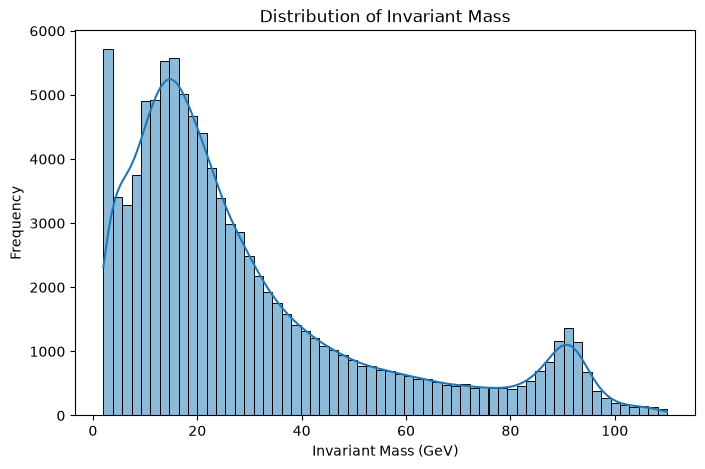

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(df["M"], bins=60, kde=True)

plt.title("Distribution of Invariant Mass")

plt.xlabel("Invariant Mass (GeV)")

plt.ylabel("Frequency")

plt.show()

In [26]:
print("Mean :", df["M"].mean())
print("Median :", df["M"].median())
print("Standard Deviation :", df["M"].std())
print("Skewness :", df["M"].skew())
print("Kurtosis :", df["M"].kurt())

Mean : 30.01345286655931
Median : 21.2831
Standard Deviation : 25.246478153200393
Skewness : 1.3020484193600481
Kurtosis : 0.780458864280285


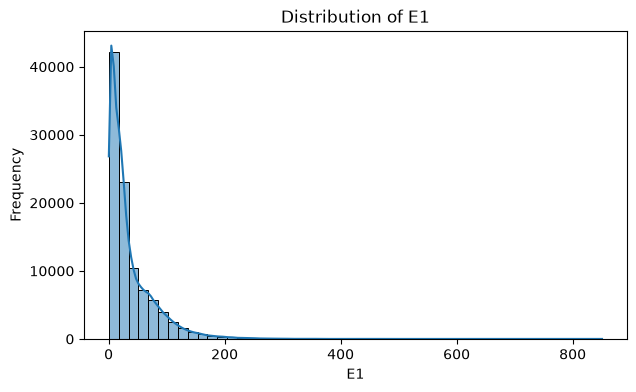

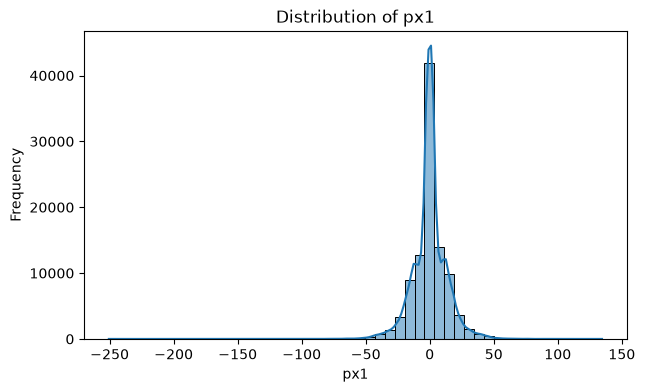

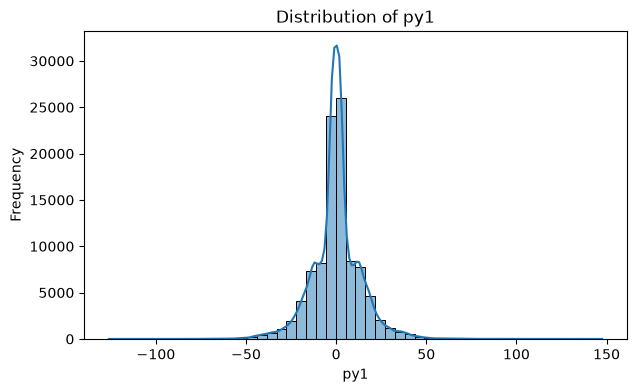

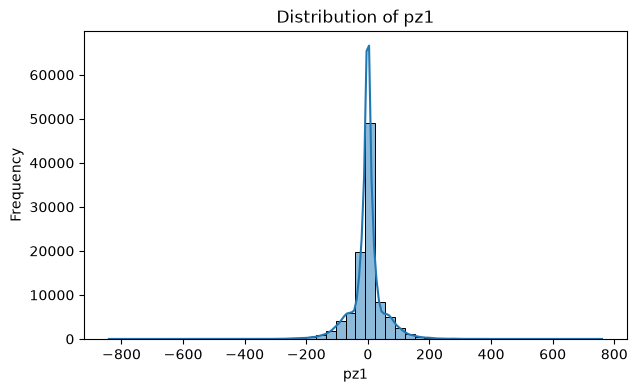

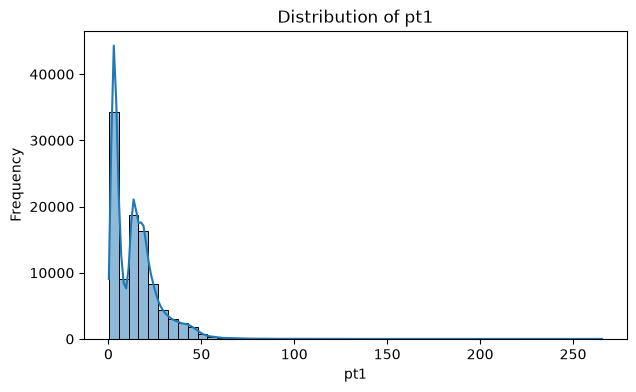

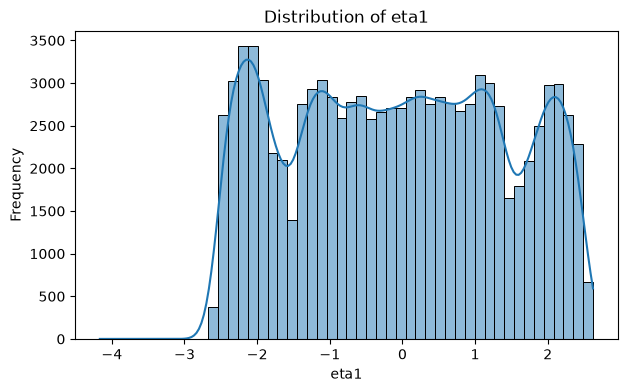

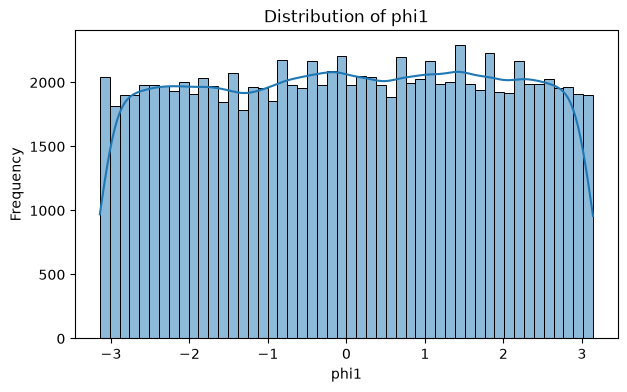

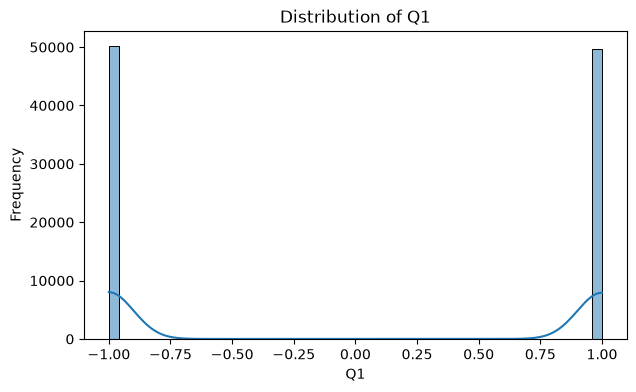

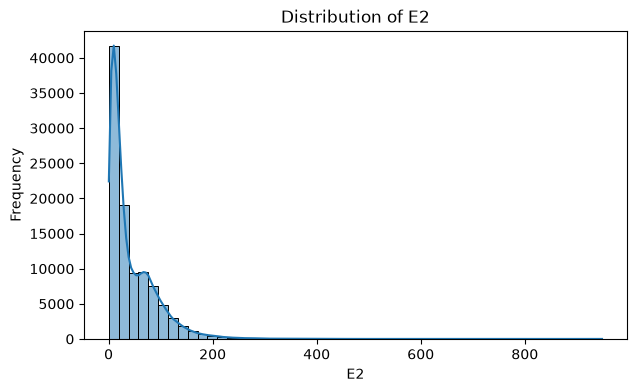

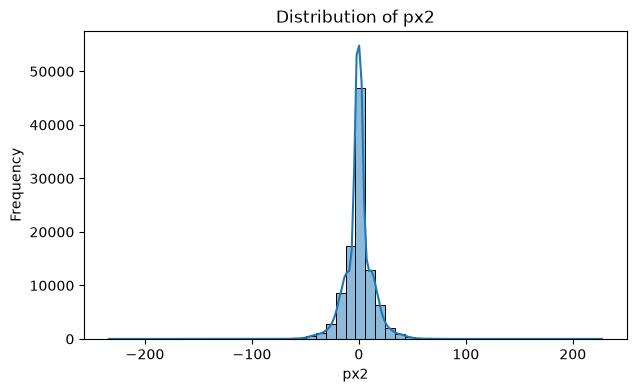

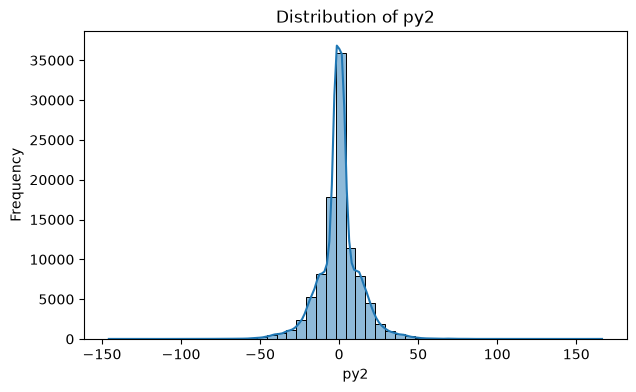

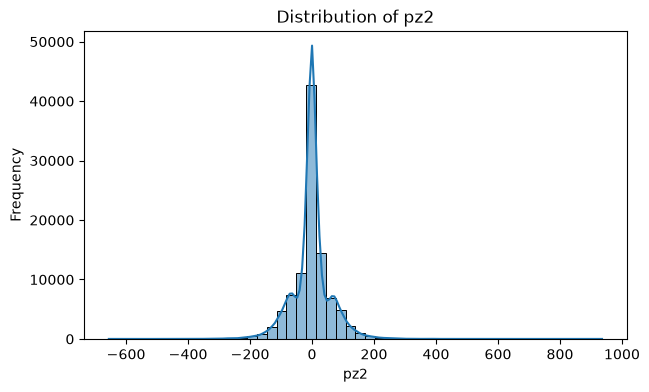

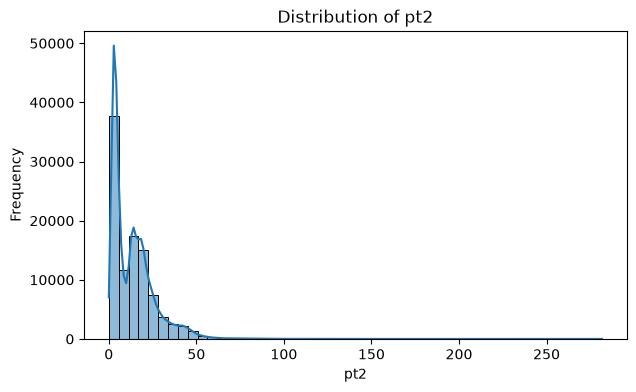

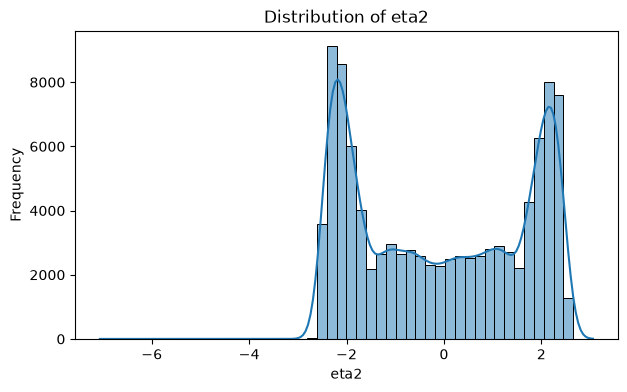

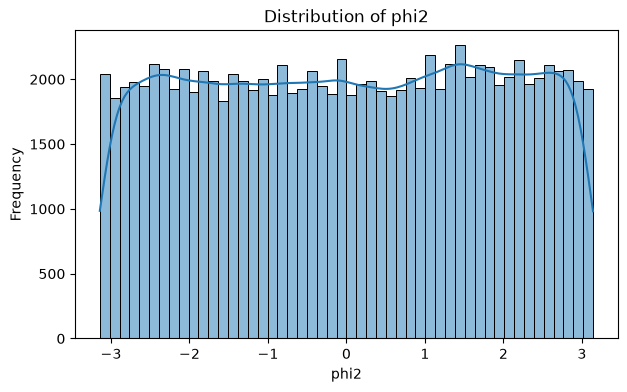

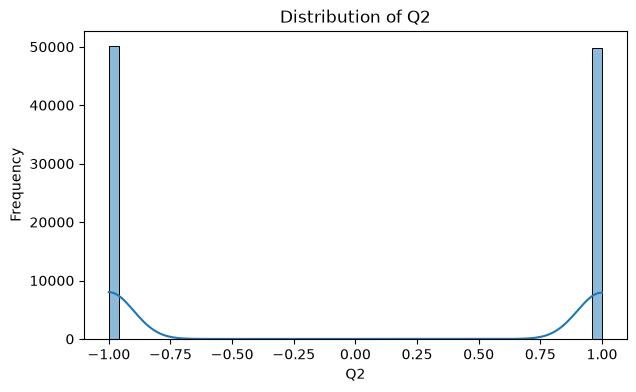

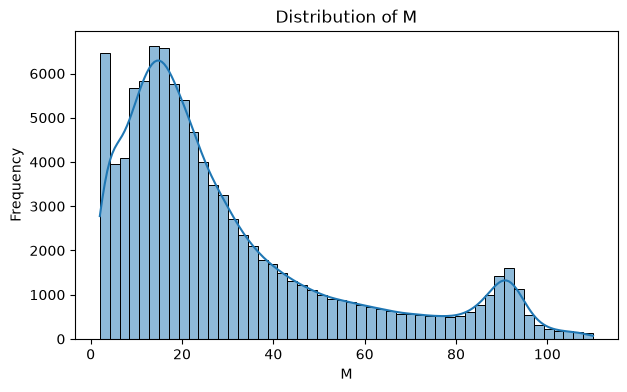

In [27]:
for column in df.columns:

    plt.figure(figsize=(7,4))

    sns.histplot(df[column], bins=50, kde=True)

    plt.title(f"Distribution of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.show()

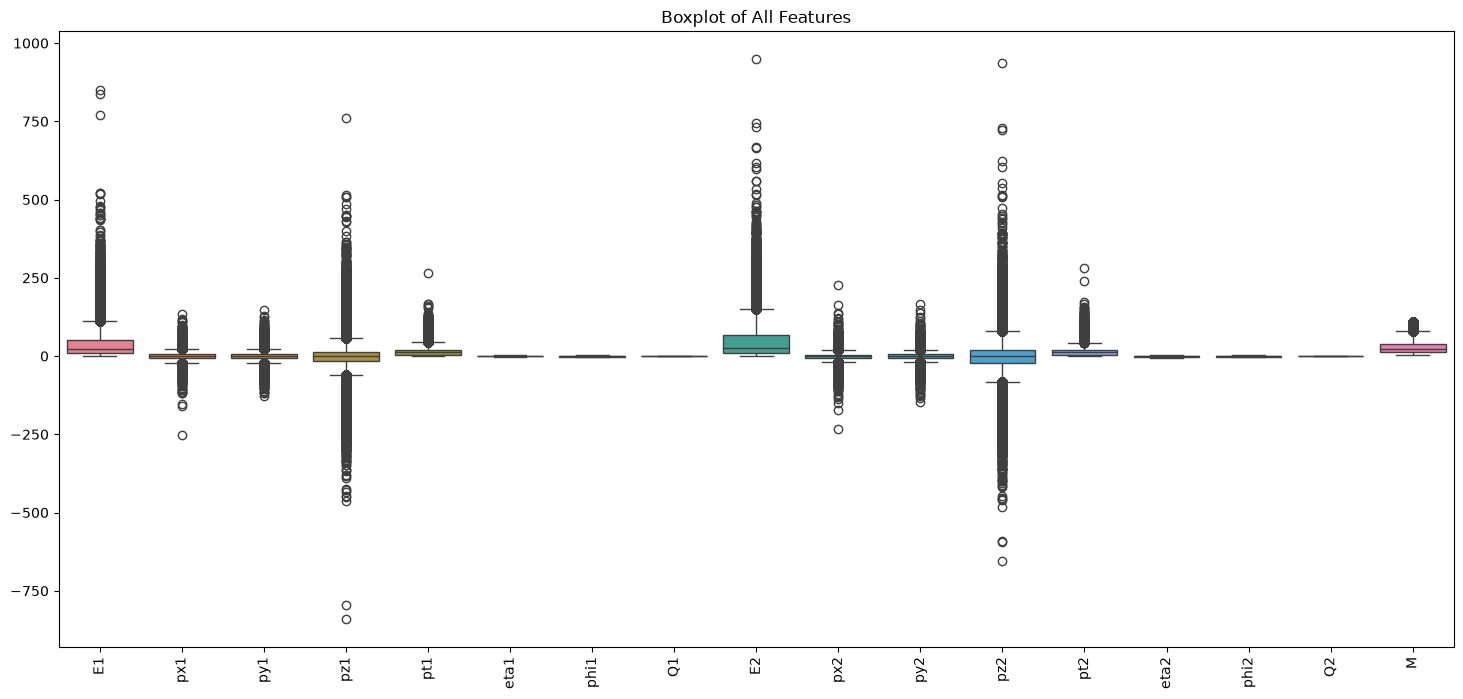

In [28]:
plt.figure(figsize=(18,8))

sns.boxplot(data=df)

plt.xticks(rotation=90)

plt.title("Boxplot of All Features")

plt.show()

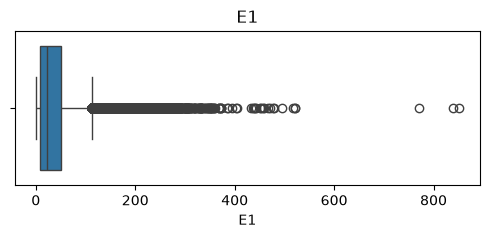

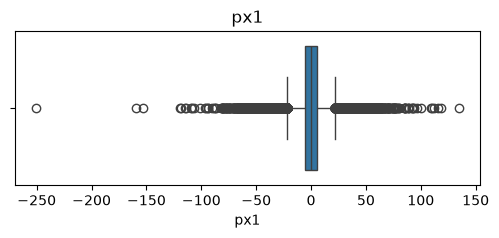

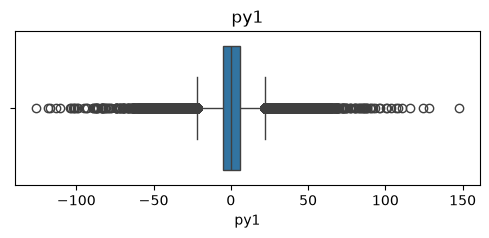

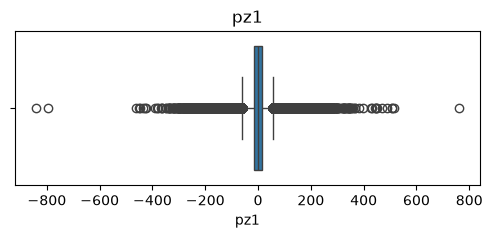

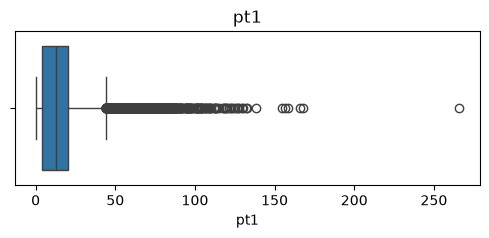

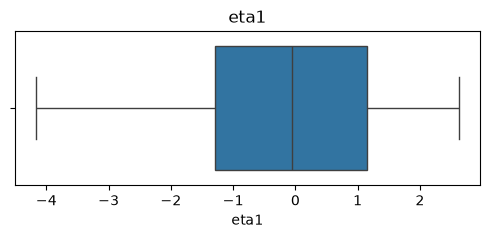

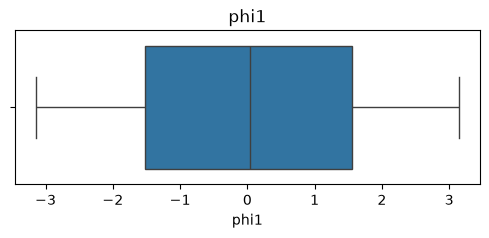

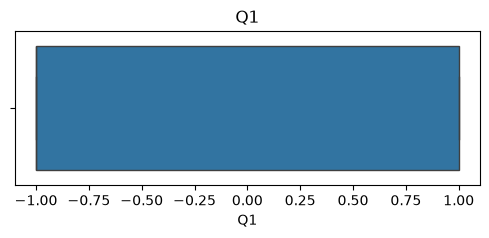

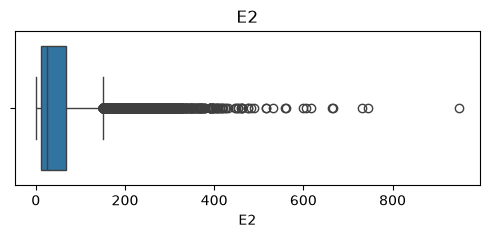

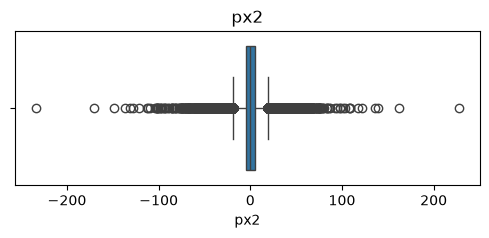

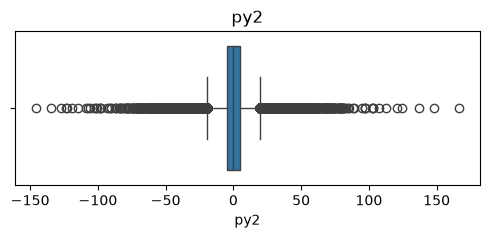

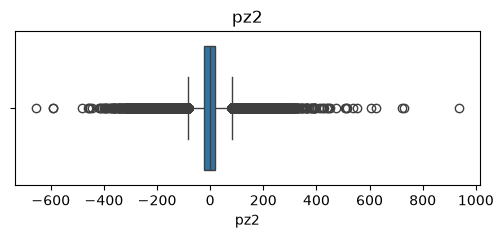

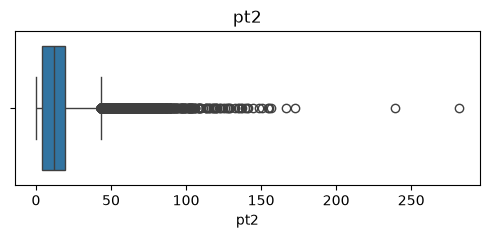

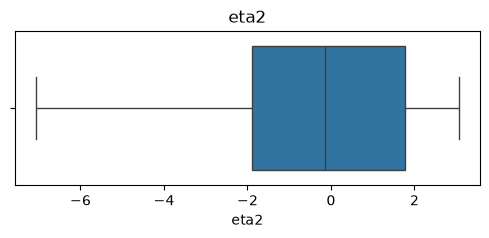

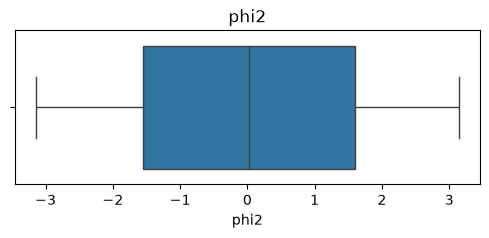

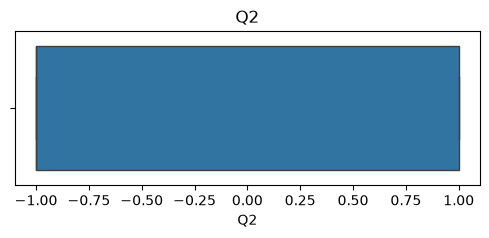

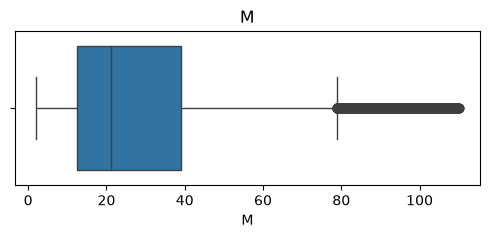

In [29]:
for column in df.columns:

    plt.figure(figsize=(6,2))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

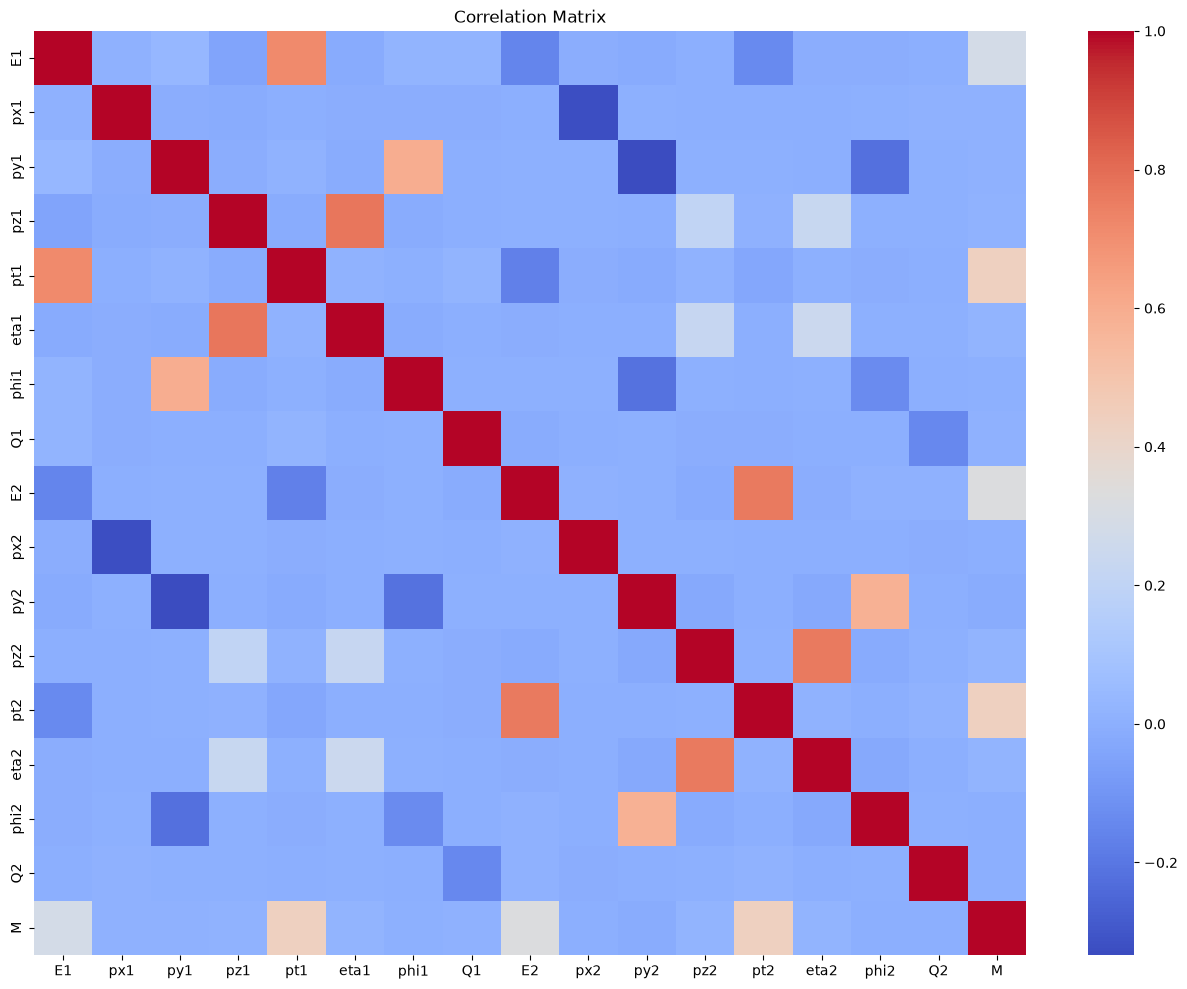

In [30]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(16,12))

sns.heatmap(corr,
            cmap="coolwarm",
            annot=False)

plt.title("Correlation Matrix")

plt.show()

In [31]:
target_corr = corr["M"].sort_values(ascending=False)

target_corr

M       1.000
pt1     0.437
pt2     0.437
E2      0.325
E1      0.285
eta2    0.019
eta1    0.017
pz2     0.016
pz1     0.012
py1     0.008
px1     0.006
Q1      0.006
phi1    0.002
Q2     -0.000
phi2   -0.004
px2    -0.004
py2    -0.012
Name: M, dtype: float64

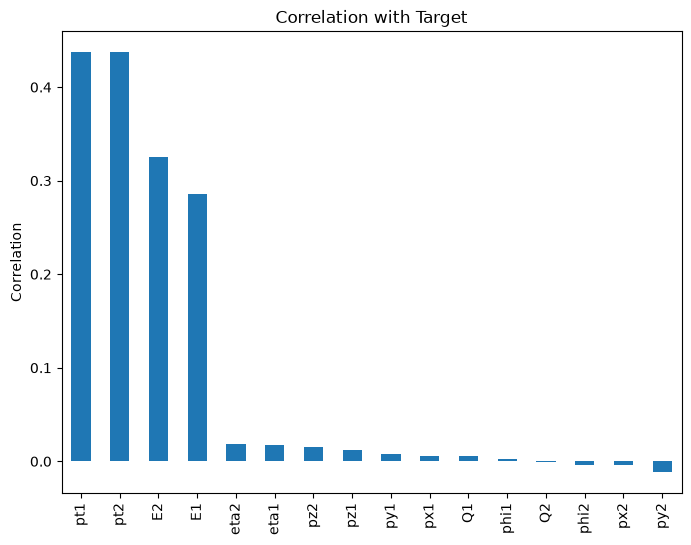

In [32]:
plt.figure(figsize=(8,6))

target_corr.drop("M").plot(kind="bar")

plt.title("Correlation with Target")

plt.ylabel("Correlation")

plt.show()

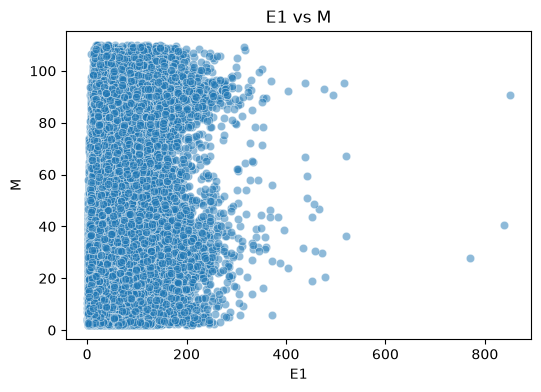

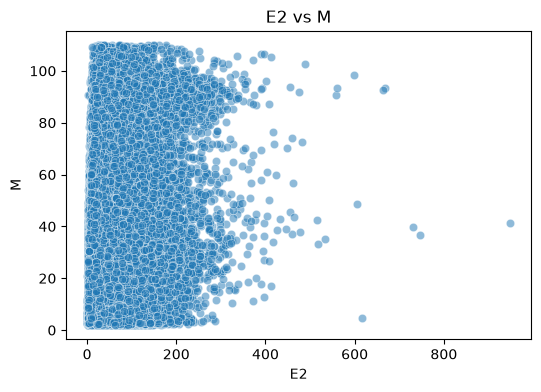

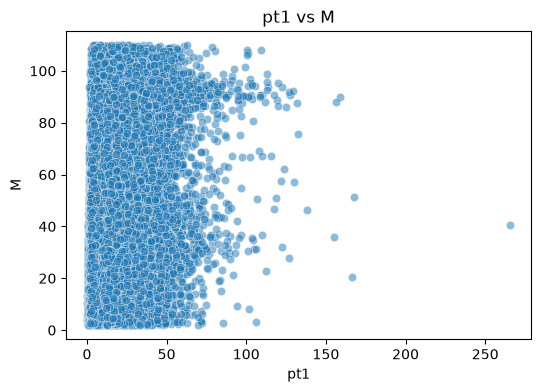

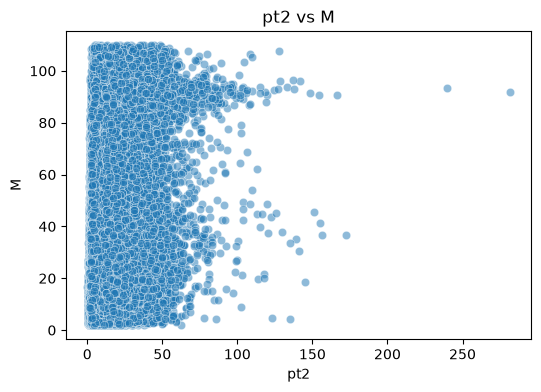

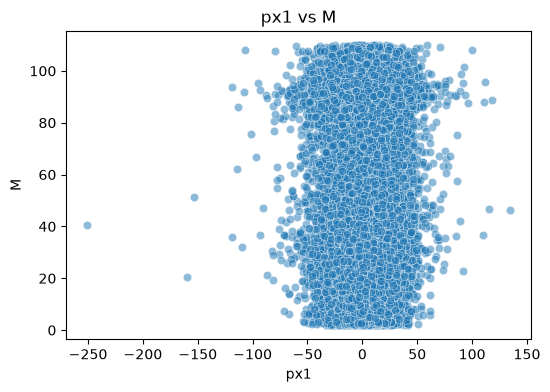

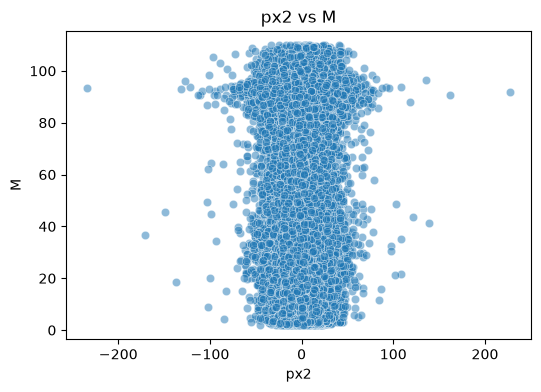

In [33]:
important_features = [
    "E1",
    "E2",
    "pt1",
    "pt2",
    "px1",
    "px2"
]

for feature in important_features:

    plt.figure(figsize=(6,4))

    sns.scatterplot(
        data=df,
        x=feature,
        y="M",
        alpha=0.5
    )

    plt.title(f"{feature} vs M")

    plt.show()

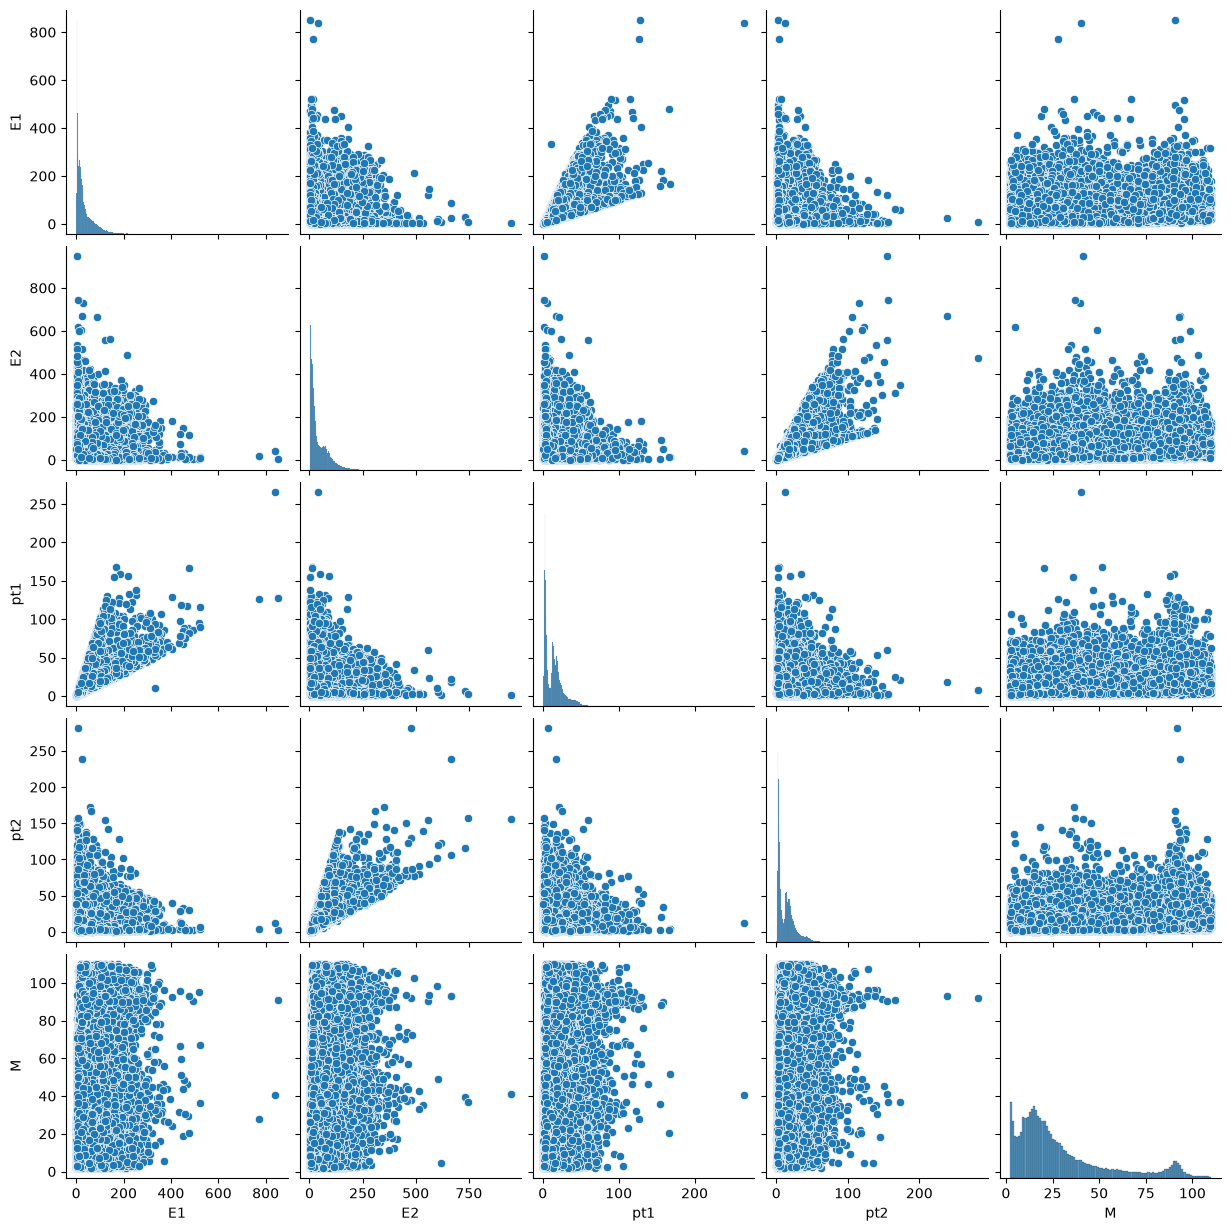

In [34]:
selected = [
    "E1",
    "E2",
    "pt1",
    "pt2",
    "M"
]

sns.pairplot(df[selected])

plt.show()

In [37]:
# =====================================================
# Skewness Analysis
# =====================================================
# Skewness measures the asymmetry of a distribution.
#
# Skewness > 0  : Right-skewed distribution
# Skewness < 0  : Left-skewed distribution
# Skewness ≈ 0  : Approximately symmetric distribution
# =====================================================

skewness = df.skew().sort_values(ascending=False)

print("Skewness of Features:\n")

skewness

Skewness of Features:



E1      2.513
E2      2.210
pt2     1.994
pt1     1.741
M       1.302
pz2     0.073
eta2    0.054
py1     0.032
eta1    0.023
Q1      0.011
Q2      0.009
phi2   -0.020
phi1   -0.023
py2    -0.040
pz1    -0.051
px2    -0.063
px1    -0.119
dtype: float64

In [38]:
# =====================================================
# Kurtosis Analysis
# =====================================================
# Kurtosis measures the "tailedness" of a distribution.
#
# High Kurtosis:
#     More extreme values (heavy tails)
#
# Low Kurtosis:
#     Fewer extreme values (light tails)
# =====================================================

kurtosis = df.kurtosis().sort_values(ascending=False)

print("Kurtosis of Features:\n")

kurtosis

Kurtosis of Features:



E1     12.351
pt2     9.960
E2      9.925
pz1     7.743
pt1     7.294
px2     7.260
px1     5.345
pz2     5.294
py2     5.244
py1     4.062
M       0.780
eta1   -1.168
phi1   -1.184
phi2   -1.212
eta2   -1.552
Q1     -2.000
Q2     -2.000
dtype: float64

In [39]:
# =====================================================
# Variance Analysis
# =====================================================
# Variance measures the spread of each feature.
#
# High Variance:
#     Feature values vary significantly.
#
# Low Variance:
#     Feature contains less information.
# =====================================================

variance = df.var().sort_values(ascending=False)

print("Variance of Features:\n")

variance

Variance of Features:



pz2    3773.955
pz1    2662.732
E2     2185.820
E1     1698.610
M       637.385
py1     181.459
px1     179.682
py2     173.446
px2     172.344
pt2     155.281
pt1     153.490
phi2      3.301
phi1      3.238
eta2      3.021
eta1      2.138
Q2        1.000
Q1        1.000
dtype: float64

In [40]:
# =====================================================
# Detect Outliers using IQR
# =====================================================
# Outliers are detected using:
#
# Lower Bound = Q1 - 1.5 × IQR
#
# Upper Bound = Q3 + 1.5 × IQR
#
# NOTE:
# Since this is a High Energy Physics dataset,
# outliers may represent genuine collision events.
# Therefore, we only identify them and do NOT remove them.
# =====================================================

outlier_summary = {}

for column in df.columns:

    # Calculate Quartiles
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    # Calculate Interquartile Range
    IQR = Q3 - Q1

    # Calculate Bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count Outliers
    outliers = ((df[column] < lower_bound) |
                (df[column] > upper_bound)).sum()

    outlier_summary[column] = outliers

# Convert Dictionary into DataFrame
outlier_df = pd.DataFrame(
    outlier_summary.items(),
    columns=["Feature", "Number of Outliers"]
)

# Sort Features by Number of Outliers
outlier_df.sort_values(
    by="Number of Outliers",
    ascending=False
)

,Feature,Number of Outliers
3,pz1,19169
11,pz2,16356
10,py2,12238
9,px2,12085
2,py1,9634
1,px1,9337
16,M,8979
0,E1,5721
8,E2,3288
12,pt2,3154


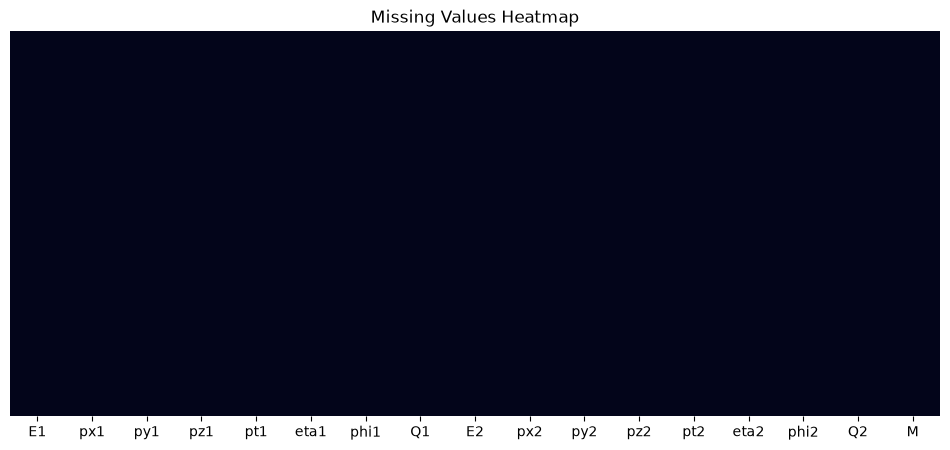

In [41]:
# =====================================================
# Missing Values Heatmap
# =====================================================
# This visualization helps identify missing values
# in the dataset.
#
# White Area:
#     No Missing Values
#
# Colored Area:
#     Missing Values Present
# =====================================================

plt.figure(figsize=(12,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Heatmap")

plt.show()

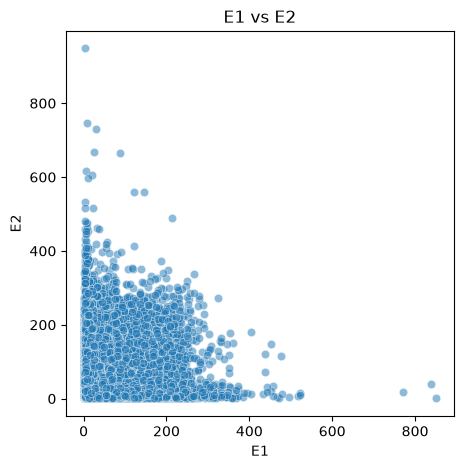

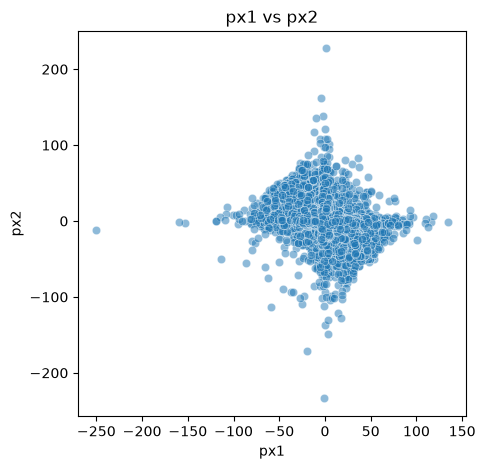

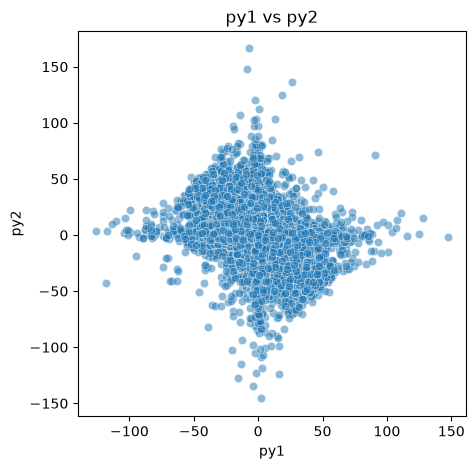

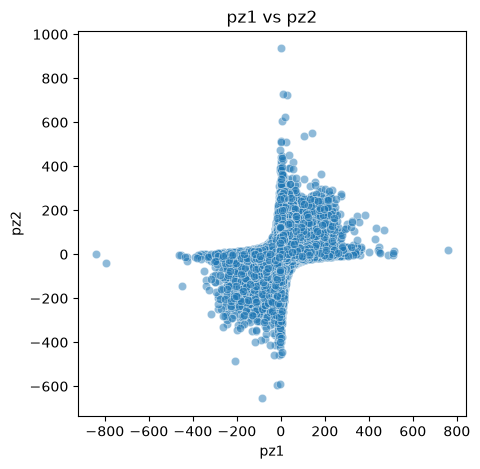

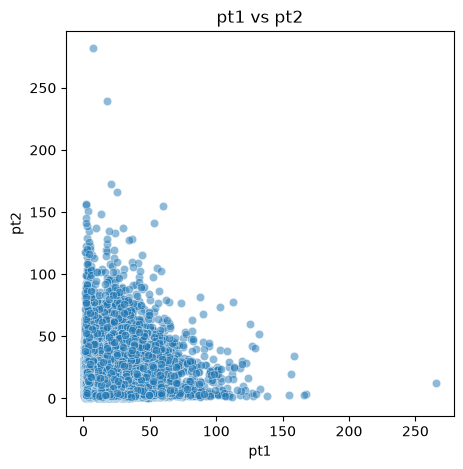

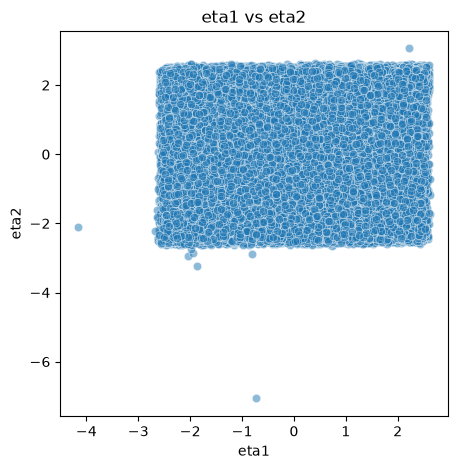

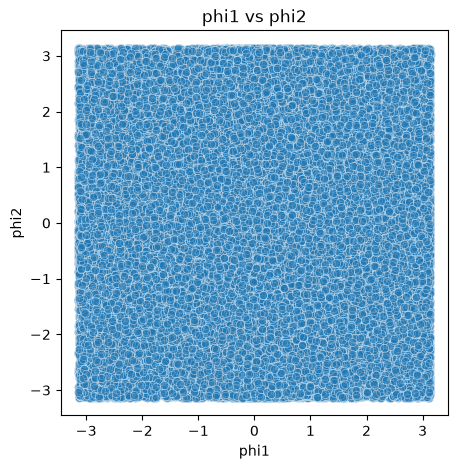

In [42]:
# =====================================================
# Relationship Between Electron 1 and Electron 2
# =====================================================
# Compare corresponding measurements of the two electrons.
#
# These plots help understand whether the properties
# of Electron 1 and Electron 2 show similar trends.
# =====================================================

feature_pairs = [

    ("E1","E2"),
    ("px1","px2"),
    ("py1","py2"),
    ("pz1","pz2"),
    ("pt1","pt2"),
    ("eta1","eta2"),
    ("phi1","phi2")

]

for x_feature, y_feature in feature_pairs:

    plt.figure(figsize=(5,5))

    sns.scatterplot(
        data=df,
        x=x_feature,
        y=y_feature,
        alpha=0.5
    )

    plt.title(f"{x_feature} vs {y_feature}")

    plt.xlabel(x_feature)
    plt.ylabel(y_feature)

    plt.show()

In [44]:
# =====================================================
# Top Features Correlated with Invariant Mass (M)
# =====================================================

target_corr = (
    corr["M"]
    .drop("M")
    .sort_values(ascending=False)
)

print("Features Ranked by Correlation with Invariant Mass:\n")

print(target_corr.round(3))

Features Ranked by Correlation with Invariant Mass:

pt1     0.437
pt2     0.437
E2      0.325
E1      0.285
eta2    0.019
eta1    0.017
pz2     0.016
pz1     0.012
py1     0.008
px1     0.006
Q1      0.006
phi1    0.002
Q2     -0.000
phi2   -0.004
px2    -0.004
py2    -0.012
Name: M, dtype: float64


In [45]:
# =====================================================
# EDA Summary
# =====================================================

print("=" * 70)
print("Exploratory Data Analysis Summary")
print("=" * 70)

print("""

1. Dataset successfully loaded and explored.

2. No missing values detected.

3. No duplicate records found.

4. Target variable (Invariant Mass - M)
   shows its own characteristic distribution.

5. Several momentum and energy features
   exhibit strong relationships with M.

6. Multiple features are highly correlated,
   indicating possible sensor redundancy.

7. Outliers are present, but they are expected
   in high-energy physics experiments and
   should not be removed without domain justification.

8. Statistical measures such as skewness,
   kurtosis, and variance were computed.

9. Correlation analysis identifies candidate
   features for Feature Selection.

10. These findings will guide:
      • Feature Engineering
      • Feature Selection
      • Sensor Purging
      • Model Training

""")

print("=" * 70)
print("Notebook 3 Completed Successfully")
print("=" * 70)

Exploratory Data Analysis Summary


1. Dataset successfully loaded and explored.

2. No missing values detected.

3. No duplicate records found.

4. Target variable (Invariant Mass - M)
   shows its own characteristic distribution.

5. Several momentum and energy features
   exhibit strong relationships with M.

6. Multiple features are highly correlated,
   indicating possible sensor redundancy.

7. Outliers are present, but they are expected
   in high-energy physics experiments and
   should not be removed without domain justification.

8. Statistical measures such as skewness,
   kurtosis, and variance were computed.

9. Correlation analysis identifies candidate
   features for Feature Selection.

10. These findings will guide:
      • Feature Engineering
      • Feature Selection
      • Sensor Purging
      • Model Training


Notebook 3 Completed Successfully
